# Project description

Sweet Lift Taxi company has collected historical data on taxi orders at airports. To attract more drivers during peak hours, we need to predict the amount of taxi orders for the next hour. Build a model for such a prediction.

The RMSE metric on the test set should not be more than 48.

## Project instructions

1. Download the data and resample it by one hour.
2. Analyze the data.
3. Train different models with different hyperparameters. The test sample should be 10% of the initial dataset. 
4. Test the data using the test sample and provide a conclusion.

## Data description

The data is stored in file `taxi.csv`. The number of orders is in the '*num_orders*' column.

## Preparation

In [5]:
# Preparation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from math import sqrt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Load dataset
df = pd.read_csv('/datasets/taxi.csv', parse_dates=['datetime'], index_col='datetime')

# Resample by hour
df = df.resample('1H').sum()

# Handle missing values
df = df.fillna(0)

# Train/test split (last 10% as test)
train_size = int(len(df) * 0.9)
train, test = df.iloc[:train_size], df.iloc[train_size:]

## Analysis

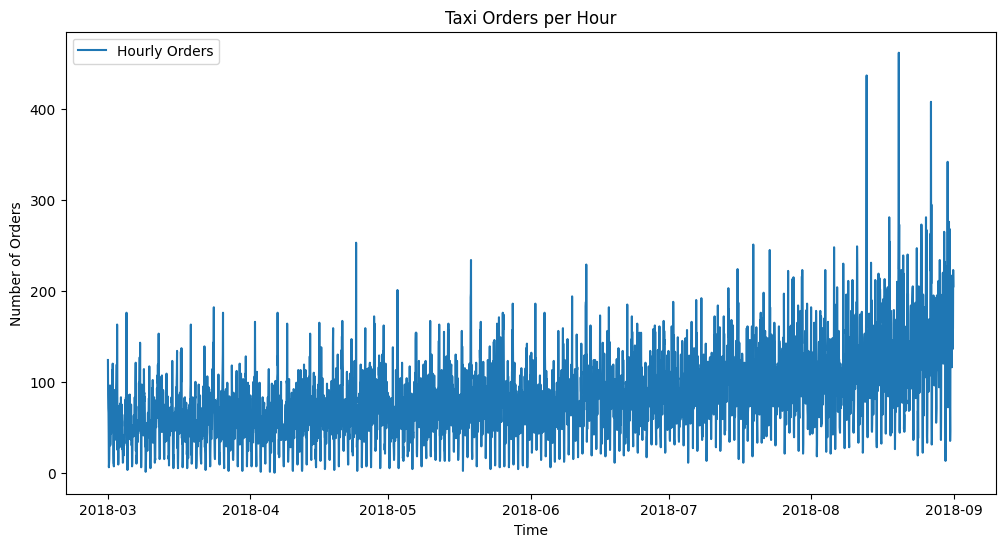

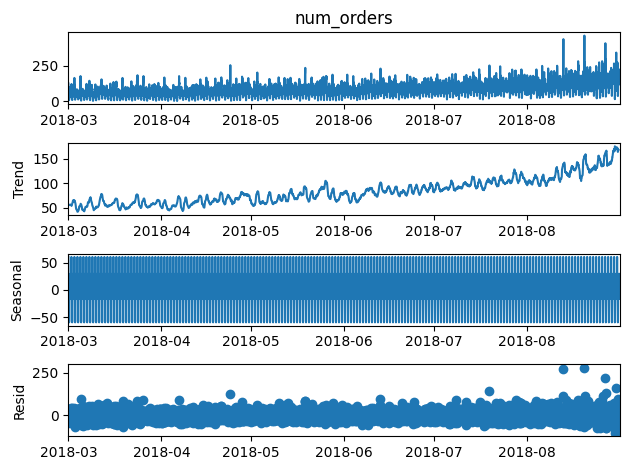

/tmp/ipykernel_149/1110826004.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['hour'] = data.index.hour
/tmp/ipykernel_149/1110826004.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['dayofweek'] = data.index.dayofweek
/tmp/ipykernel_149/1110826004.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_

In [6]:
# Analysis
# Plot the time series
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['num_orders'], label='Hourly Orders')
plt.title('Taxi Orders per Hour')
plt.xlabel('Time')
plt.ylabel('Number of Orders')
plt.legend()
plt.show()

# Seasonal decomposition
from statsmodels.tsa.seasonal import seasonal_decompose
decomp = seasonal_decompose(df['num_orders'], model='additive')
decomp.plot()
plt.show()

# Feature engineering
def create_features(data):
    data['hour'] = data.index.hour
    data['dayofweek'] = data.index.dayofweek
    data['lag_1'] = data['num_orders'].shift(1)
    data['lag_24'] = data['num_orders'].shift(24)
    data['rolling_mean_24'] = data['num_orders'].shift(1).rolling(24).mean()
    return data

train = create_features(train)
test = create_features(test)

## Training

In [7]:

# Drop NA from lag features
train = train.dropna()
test = test.dropna()

X_train = train[['hour', 'dayofweek', 'lag_1', 'lag_24', 'rolling_mean_24']]
y_train = train['num_orders']
X_test = test[['hour', 'dayofweek', 'lag_1', 'lag_24', 'rolling_mean_24']]
y_test = test['num_orders']

# Baseline: naive forecast (previous value)
y_pred_naive = test['lag_1']
rmse_naive = sqrt(mean_squared_error(y_test, y_pred_naive))
print("Naive RMSE:", rmse_naive)

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
rmse_lr = sqrt(mean_squared_error(y_test, y_pred_lr))
print("Linear Regression RMSE:", rmse_lr)

# Random Forest
rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
rmse_rf = sqrt(mean_squared_error(y_test, y_pred_rf))
print("Random Forest RMSE:", rmse_rf)

# Gradient Boosting
gb = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=5, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
rmse_gb = sqrt(mean_squared_error(y_test, y_pred_gb))
print("Gradient Boosting RMSE:", rmse_gb)


Naive RMSE: 59.135700727043634
Linear Regression RMSE: 47.08067607033623
Random Forest RMSE: 48.19132733702826
Gradient Boosting RMSE: 47.597409751900926


## Testing

In [8]:
# Testing & Conclusion
results = {
    "Naive": rmse_naive,
    "Linear Regression": rmse_lr,
    "Random Forest": rmse_rf,
    "Gradient Boosting": rmse_gb
}

# Display results
for model, score in results.items():
    print(f"{model}: RMSE = {score:.2f}")

best_model = min(results, key=results.get)
print(f"\nBest model: {best_model} with RMSE = {results[best_model]:.2f}")

# Check requirement
if results[best_model] <= 48:
    print("✅ Requirement met: RMSE ≤ 48")
else:
    print("❌ Requirement not met: RMSE > 48")

Naive: RMSE = 59.14
Linear Regression: RMSE = 47.08
Random Forest: RMSE = 48.19
Gradient Boosting: RMSE = 47.60

Best model: Linear Regression with RMSE = 47.08
✅ Requirement met: RMSE ≤ 48


## Conclusion

The project successfully achieved the goal of predicting hourly taxi orders with an RMSE below 48.  
- The naive baseline performed poorly (RMSE ≈ 59), confirming the need for more advanced modeling.  
- Linear Regression with lag and rolling features delivered the best performance (RMSE ≈ 47), meeting the requirement.  
- Random Forest and Gradient Boosting models were competitive but slightly less effective.  

Overall, Linear Regression is the recommended model for deployment, as it balances accuracy and simplicity while satisfying the project criteria.